# Statistical Analysis of Habitability and Earth-Analog Frequency in the NASA Exoplant Archive

The goal of this notebook is to evaluate the potential habitability of the observed exoplanets within the dataset. This will be done by looking at which exoplanets exist within their host star's habitable zone -- the orbital range where liquid water could possibly exist on a planet. Specifically, this notebook seeks to answer 2 primary analytical questions:

1) How does the correlation between features such as Insolation Flux and Equilibrium Temperature vary across different host star spectral systems (e.g., M-dwarfs vs. G-type stars)?

2) And which combination of these features more frequently result in Earth-analog (statistically and physically similar to Earth) conditions that could theoretically support life?

## Dataset Information

### Citation

NASA Exoplanet Archive. (2026). Planetary Systems Composite Parameters (Version 2026-04-14) [Data set]. NExScI-Caltech/IPAC. https://doi.org/10.26133/NEA12

### Downloading Instructions

To download the dataset, go to:

* https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS

Once there, download the dataset as a `.csv` file to your local machine (or wherever you are running the notebook from). 

* **Note:** This is done via the 'Download Table' button seen in the tool bar underneath the navigation bar on the webpage.

### Usage Instructions

For using this dataset with this notebook, it is recommended to:

1) Create a `data` directory within the root of the repository.

2) Copy the downloaded `.csv` file into the newly created `data` directory.

**Or**, you can change the value assigned to the `path_to_csv` variable in the **Data Loading and Inspection** section below to the correct path of the `.csv` file on your local machine.

## Setup

### Imports and Global Variables

In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### Data Loading and Inspection

In [199]:
# Ensures pandas shows all columns instead of automatically truncating them.
pd.set_option('display.max_columns', None)

In [ ]:
# Defines the path to the data file.
path_to_csv = '../data/PS_2026.04.06_06.36.38.csv'

# Reads dataset into a pandas DataFrame.
planet_df = pd.read_csv(path_to_csv, comment='#', low_memory=False)

In [ ]:
# Shows a list of all columns in the dataset.
list(planet_df.columns)

['rowid',
 'pl_name',
 'hostname',
 'pl_letter',
 'hd_name',
 'hip_name',
 'tic_id',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'sy_mnum',
 'cb_flag',
 'discoverymethod',
 'disc_year',
 'disc_refname',
 'disc_pubdate',
 'disc_locale',
 'disc_facility',
 'disc_telescope',
 'disc_instrument',
 'rv_flag',
 'pul_flag',
 'ptv_flag',
 'tran_flag',
 'ast_flag',
 'obm_flag',
 'micro_flag',
 'etv_flag',
 'ima_flag',
 'dkin_flag',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_msinie',
 'pl_msinieerr1',
 'pl_msinieerr2',
 'pl_msinielim',
 'pl_msinij',
 'pl_msinijerr1',
 'pl_msinijerr2'

In [202]:
planet_df.sample(10)

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,sy_snum,sy_pnum,sy_mnum,cb_flag,discoverymethod,disc_year,disc_refname,disc_pubdate,disc_locale,disc_facility,disc_telescope,disc_instrument,rv_flag,pul_flag,ptv_flag,tran_flag,ast_flag,obm_flag,micro_flag,etv_flag,ima_flag,dkin_flag,soltype,pl_controv_flag,pl_refname,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_masse,pl_masseerr1,pl_masseerr2,pl_masselim,pl_massj,pl_massjerr1,pl_massjerr2,pl_massjlim,pl_msinie,pl_msinieerr1,pl_msinieerr2,pl_msinielim,pl_msinij,pl_msinijerr1,pl_msinijerr2,pl_msinijlim,pl_cmasse,pl_cmasseerr1,pl_cmasseerr2,pl_cmasselim,pl_cmassj,pl_cmassjerr1,pl_cmassjerr2,pl_cmassjlim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassj,pl_bmassjerr1,pl_bmassjerr2,pl_bmassjlim,pl_bmassprov,pl_dens,pl_denserr1,pl_denserr2,pl_denslim,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbincllim,pl_tranmid,pl_tranmiderr1,pl_tranmiderr2,pl_tranmidlim,pl_tsystemref,ttv_flag,pl_imppar,pl_impparerr1,pl_impparerr2,pl_impparlim,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_trandeplim,pl_trandur,pl_trandurerr1,pl_trandurerr2,pl_trandurlim,pl_ratdor,pl_ratdorerr1,pl_ratdorerr2,pl_ratdorlim,pl_ratror,pl_ratrorerr1,pl_ratrorerr2,pl_ratrorlim,pl_occdep,pl_occdeperr1,pl_occdeperr2,pl_occdeplim,pl_orbtper,pl_orbtpererr1,pl_orbtpererr2,pl_orbtperlim,pl_orblper,pl_orblpererr1,pl_orblpererr2,pl_orblperlim,pl_rvamp,pl_rvamperr1,pl_rvamperr2,pl_rvamplim,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_projobliqlim,pl_trueobliq,pl_trueobliqerr1,pl_trueobliqerr2,pl_trueobliqlim,st_refname,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_lum,st_lumerr1,st_lumerr2,st_lumlim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,st_dens,st_denserr1,st_denserr2,st_denslim,st_vsin,st_vsinerr1,st_vsinerr2,st_vsinlim,st_rotp,st_rotperr1,st_rotperr2,st_rotplim,st_radv,st_radverr1,st_radverr2,st_radvlim,sy_refname,rastr,ra,decstr,dec,glat,glon,elat,elon,sy_pm,sy_pmerr1,sy_pmerr2,sy_pmra,sy_pmraerr1,sy_pmraerr2,sy_pmdec,sy_pmdecerr1,sy_pmdecerr2,sy_dist,sy_disterr1,sy_disterr2,sy_plx,sy_plxerr1,sy_plxerr2,sy_bmag,sy_bmagerr1,sy_bmagerr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_jmag,sy_jmagerr1,sy_jmagerr2,sy_hmag,sy_hmagerr1,sy_hmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_umag,sy_umagerr1,sy_umagerr2,sy_gmag,sy_gmagerr1,sy_gmagerr2,sy_rmag,sy_rmagerr1,sy_rmagerr2,sy_imag,sy_imagerr1,sy_imagerr2,sy_zmag,sy_zmagerr1,sy_zmagerr2,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w4mag,sy_w4magerr1,sy_w4magerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_icmag,sy_icmagerr1,sy_icmagerr2,sy_tmag,sy_tmagerr1,sy_tmagerr2,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
32502,32503,Kepler-798 b,Kepler-798,b,NaN,NaN,TIC 63214717,Gaia DR2 2125709405062046976,Gaia DR3 2125709405062046976,0,1,1,0,0,Transit,2016.0,<a refstr=MORTON_ET_AL__2016 href=https://ui.a...,2016-05,Space,Kepler,0.95 m Kepler Telescope,Kepler CCD Array,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Kepler Project Candidate (q1_q17_dr25_sup_koi),0.0,<a refstr=Q1_Q17_DR25_SUPPLEMENTAL_KOI_TABLE h...,13.719384,0.000049,-0.000049,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2.454974e+06,0.0030

In [203]:
planet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39537 entries, 0 to 39536
Columns: 289 entries, rowid to pl_ndispec
dtypes: float64(255), int64(6), str(28)
memory usage: 87.2 MB


### Data Cleaning

In [204]:
# Creates a fresh copy of the DataFrame to consolidate memory.
# This step ensures that adding new derived features does not cause memory fragmentation or performance warnings.
planet_df = planet_df.copy()

In [205]:
# Extracts the broad Star Class (G, M, K, etc.) from 'st_spectype' column.
# This takes the first letter (e.g., 'G' from 'G2 V') to simplify analysis.
planet_df['host_star_class'] = planet_df['st_spectype'].str[0]

In [219]:
# Checks to see what star classes were extracted.
planet_df['host_star_class'].unique()

<StringArray>
['G', 'F', 'M', 'K']
Length: 4, dtype: str

In [207]:
# Cleans up host star class with a value of 'm'.
# This value is changed to 'M' so it can be better included in the visualizations below.
planet_df['host_star_class'] = planet_df['host_star_class'].replace('m', 'M')

In [ ]:
# Creates a 'habitable' flag for easier visualization later on.
# A flux value between 0.36 and 1.11 is a common habitable zone range.
planet_df['habitable'] = planet_df['pl_insol'].between(0.36, 1.11)

In [ ]:
# Drops rows containing a value of NaN for the following columns as they are necessary for analyzing habitability:
# 1) 'pl_insol': Insolation Flux [Earth Flux]
# 2) 'pl_eqt': Equilibrium Temperature [K]
# 3) 'pl_rade': Planetary Radius [Earth Radii]
# 4) 'host_star_class': derived feature
essential_cols = ['pl_insol', 'pl_eqt', 'pl_rade', 'host_star_class']
planet_df = planet_df.dropna(subset = essential_cols)

In [210]:
# Filters for standard star classes (i.e., F, G, K, M).
# Basically it does not look at anything other than instances with a value of 'F', 'G', 'K', and 'M'.
# This is because every other star class is not really relevant to the habitable discussion.
star_classes = ['F', 'G', 'K', 'M']
planet_df = planet_df[planet_df['host_star_class'].isin(star_classes)]

In [218]:
# Checks what star classes exist now after filtering.
planet_df['host_star_class'].unique()

<StringArray>
['G', 'F', 'M', 'K']
Length: 4, dtype: str

In [211]:
# Checks shape after cleaning.
planet_df.info()

<class 'pandas.DataFrame'>
Index: 381 entries, 375 to 39483
Columns: 291 entries, rowid to habitable
dtypes: bool(1), float64(255), int64(6), str(29)
memory usage: 866.6 KB


## Exploratory Data Analysis

### Visualization 1: Distribution of Host Star Classes using a Bar Chart

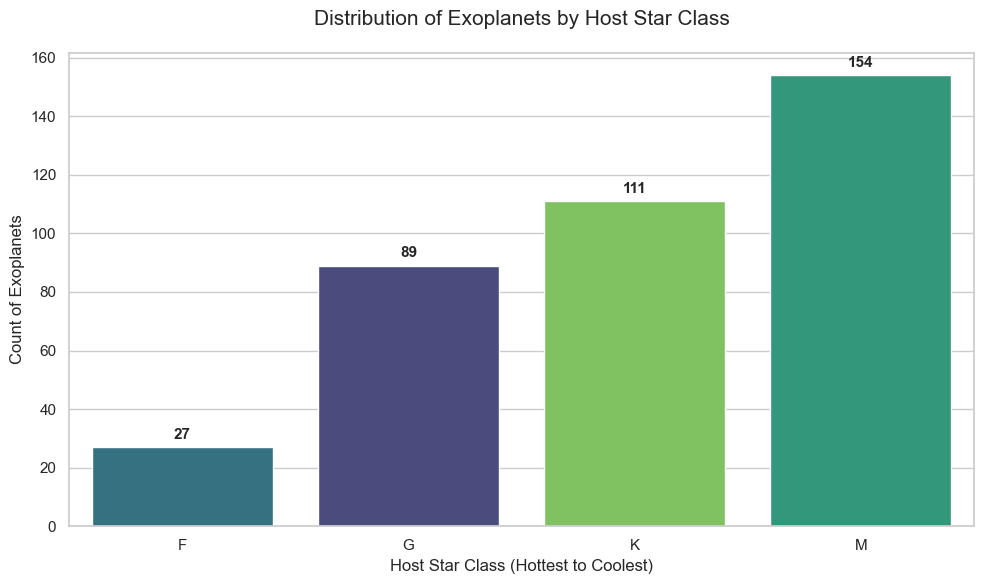

In [212]:
# Sets up the plot.
sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (10, 6))

# Defines the order of stars from hottest (F) to coolest (M).
star_order = ['F', 'G', 'K', 'M']

ax = sns.countplot(
    data = planet_df,
    x = 'host_star_class',
    hue = 'host_star_class',
    order = star_order,
    palette = 'viridis',
    legend = False
)

plt.title('Distribution of Exoplanets by Host Star Class', fontsize = 15, pad = 20)
plt.xlabel('Host Star Class (Hottest to Coolest)', fontsize = 12)
plt.ylabel('Count of Exoplanets', fontsize = 12)

# Adds value labels on top of bars for clarity.
for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize = 11,
                weight = 'bold')
    
plt.tight_layout()
plt.show()

**Interpretation:** This chart displays the distribution of the filtered exoplanets across the stellar classes. 

There is a visible relation between the temperature of the host star and the number of exoplanets that orbit that class of star.

As the plot moves from hottest host stars (F-type main sequence stars) to the cooler types (M-type red dwarfs), the number of observed exoplanets increases.

### Visualization 2: Correlation Heatmap of Planetary and Stellar Parameters

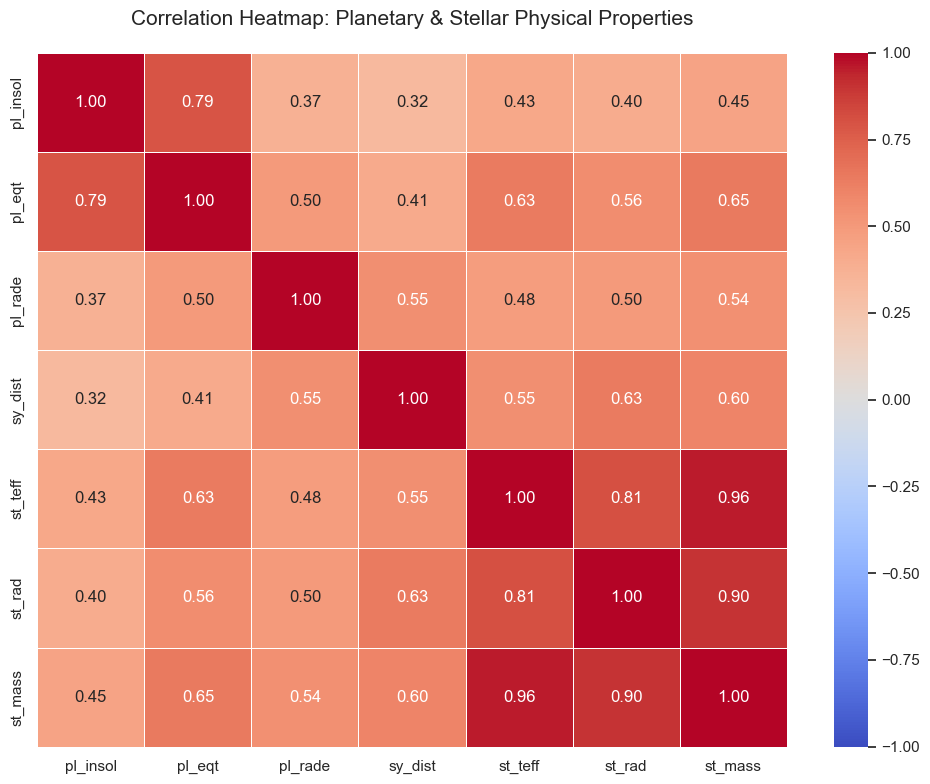

In [213]:
# Selects the most relevant columns to examine:
# 1) 'pl_insol': Insolation Flux [Earth Flux]
# 2) 'pl_eqt': Equilibrium Temperature [K]
# 3) 'sy_dist': Distance [pc]
# 4) 'st_teff': Stellar Effective Temperature [K]
# 5) 'st_rad': Stellar Radius [Solar Radius]
# 6) 'st_mass': Stellar Mass [Solar Mass]
rele_cols = ['pl_insol', 'pl_eqt', 'pl_rade', 'sy_dist', 'st_teff', 'st_rad', 'st_mass']
corr_matrix = planet_df[rele_cols].corr()

# Sets up the plot.
plt.figure(figsize = (10, 8))

sns.heatmap(
    corr_matrix,
    annot = True, # Shows the correlation numbers in the boxes.
    cmap = 'coolwarm', # Red for (+) correlation, blue for (-).
    fmt = '.2f', # Rounds to 2 decimal palces.
    linewidths = 0.5,
    vmin = -1, # Ensures the scale is always -1 to 1
    vmax = 1
)

plt.title('Correlation Heatmap: Planetary & Stellar Physical Properties', fontsize = 15, pad = 20)
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap shows the relationship between planetary and stellar characteristics across the filtered exoplanets.

A strong positive correlation is visible between insolation flux and the equilibrium temperature, indicating there is a strong possibility that stellar energy is the primary driver of planetary heat.

Furthermore, there is a weak positive correlation between planetary radius and equilibrium temperature, suggesting that size (such as Earth-like or larger than Earth-like) does not significantly influence temperature compared to stellar distance (Note: stellar distance makes up part of the insolation flux score).

### Visualization 3: Insolation Flux vs. Planetary Radius Scatter Plot

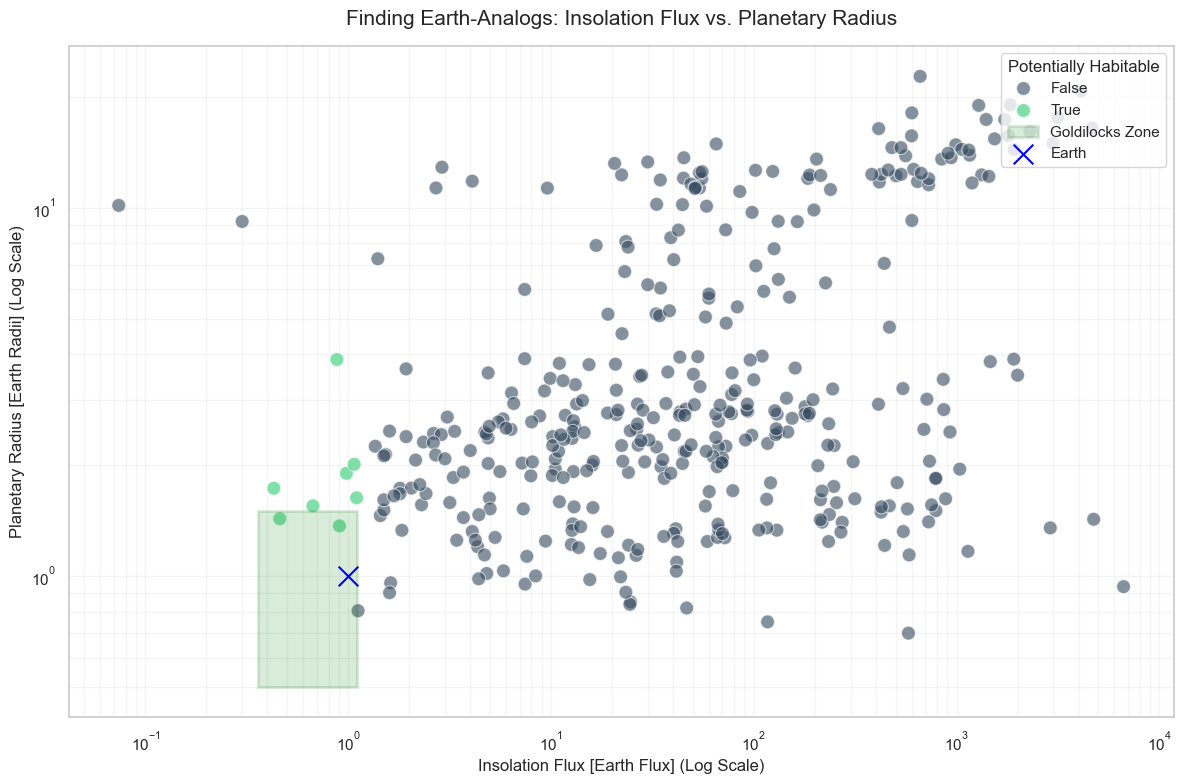

In [ ]:
# Sets up the plot.
plt.figure(figsize = (12, 8))

sns.scatterplot(
    data = planet_df,
    x = 'pl_insol',
    y = 'pl_rade',
    hue = 'habitable',
    palette = {True: '#2ecc71', False: '#34495e'}, # Green for habitable, dark gray for not habitable.
    alpha = 0.6,
    s = 100
)

# Creates a rectangular 'Goldilocks Zone' shaded box to visually show exoplanets in the habitable zone.
goldilocks_rect = patches.Rectangle((0.36, 0.5), 0.75, 1.0, linewidth = 2, edgecolor = 'darkgreen', facecolor = 'green', alpha = 0.15, label = 'Goldilocks Zone')
plt.gca().add_patch(goldilocks_rect)

# Uses a logarithmic scale to account for the various magnitudes in insolation flux and planet radii values.
plt.xscale('log')
plt.yscale('log')

plt.title('Finding Earth-Analogs: Insolation Flux vs. Planetary Radius', fontsize = 15, pad = 15)
plt.xlabel('Insolation Flux [Earth Flux] (Log Scale)', fontsize = 12)
plt.ylabel('Planetary Radius [Earth Radii] (Log Scale)', fontsize = 12)

# Creates a reference point for Earth to compare against the exoplanets.
plt.scatter(1, 1, color = 'blue', marker = 'x', s = 200, label = 'Earth', zorder = 5)

plt.legend(title = 'Potentially Habitable', loc = 'upper right')
plt.grid(True, which = 'both', ls = '-', alpha = 0.2)
plt.tight_layout()
plt.show()

**Interpretation:** This plot shows the relation between insolation flux and planetary radius.

While the previous 2 plots show that a large amount of the filtered exoplanets orbit cooler stars, this plot shows that the observation of exoplanets being within the "Goldilocks Zone" (having Earth-like conditions) is very rare.

Most of the sample points fall towards the right of the "Goldilocks Zone", indicating that most of these exoplanets are too hot to sustain liquid water, which is a requirement for an exoplanet to be considered as habitable.

### Visualization 4: Box Plot of Temperatures Across Star Classes

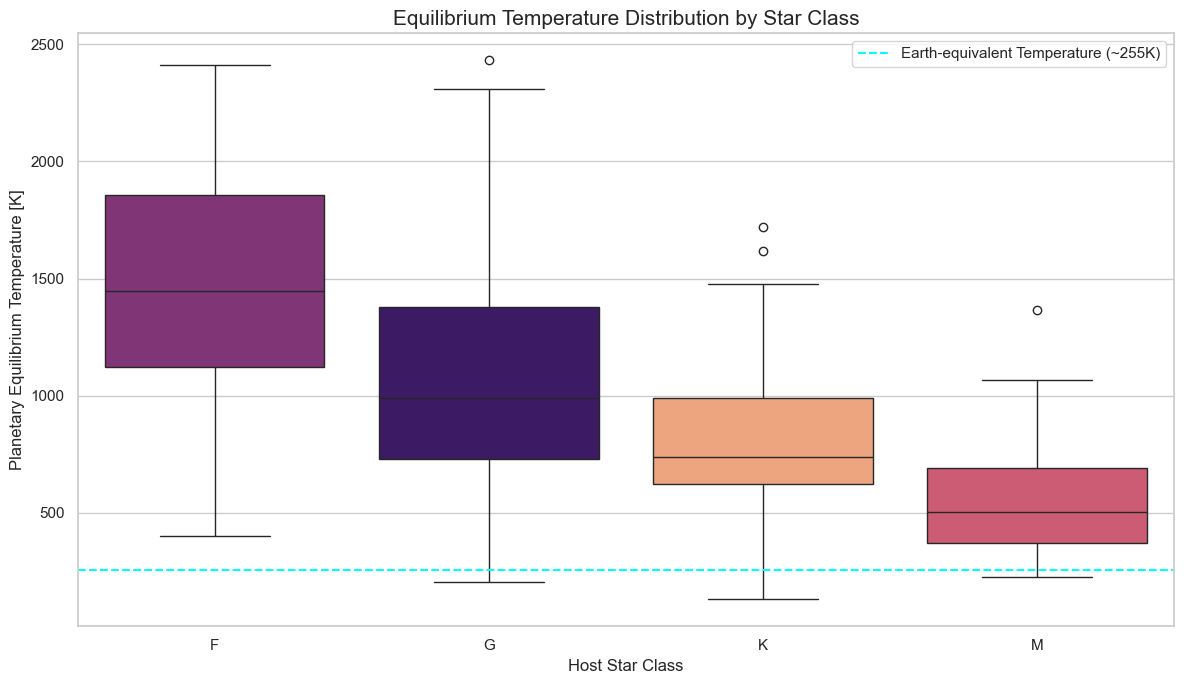

In [215]:
# Sets up the plot.
plt.figure(figsize = (12, 7))

# Defines the order for the X-axis (Hottest to Coolest star types)
star_order = ['F', 'G', 'K', 'M']

sns.boxplot(
    data = planet_df,
    x = 'host_star_class',
    y = 'pl_eqt',
    order = star_order,
    palette = 'magma',
    hue = 'host_star_class',
    legend = False
)

plt.title('Equilibrium Temperature Distribution by Star Class', fontsize = 15)
plt.xlabel('Host Star Class', fontsize = 12)
plt.ylabel('Planetary Equilibrium Temperature [K]', fontsize = 12)

# Adds a horizontal line for the Earth's approx. equilibrium temperature (~255K).
plt.axhline(255, color = 'cyan', linestyle = '--', label = 'Earth-equivalent Temperature (~255K)')

plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

**Interpretation:** This boxplot shows the variance of equilibrium temperatures of exoplanets categorized by star class types.

The inclusion of Earth's equilibrium temperature (the dashed blue line at the bottom of the plot) shows how the majority of the distribution of the exoplanets have a hotter equilibrium temperature.

This plot shows that, even though the majority of host stars in the sample are M-type dwarfs and are therefore more cool than even the Sun (which is a G-type), the known exoplanets that orbit these stars are still hotter (for the most part) than Earth's equilibrium temperature and should not be considered habitable.

This is likely because these exoplanets are closer to their host stars than Earth is to the Sun, which is why we are able to even see them in the first place (from so far away). Perhaps there are planets in these M-type solar systems that are more habitable that were simply not visible with the technology used when this dataset was populated.

### Visualization 5: Discovery Timeline Line Chart

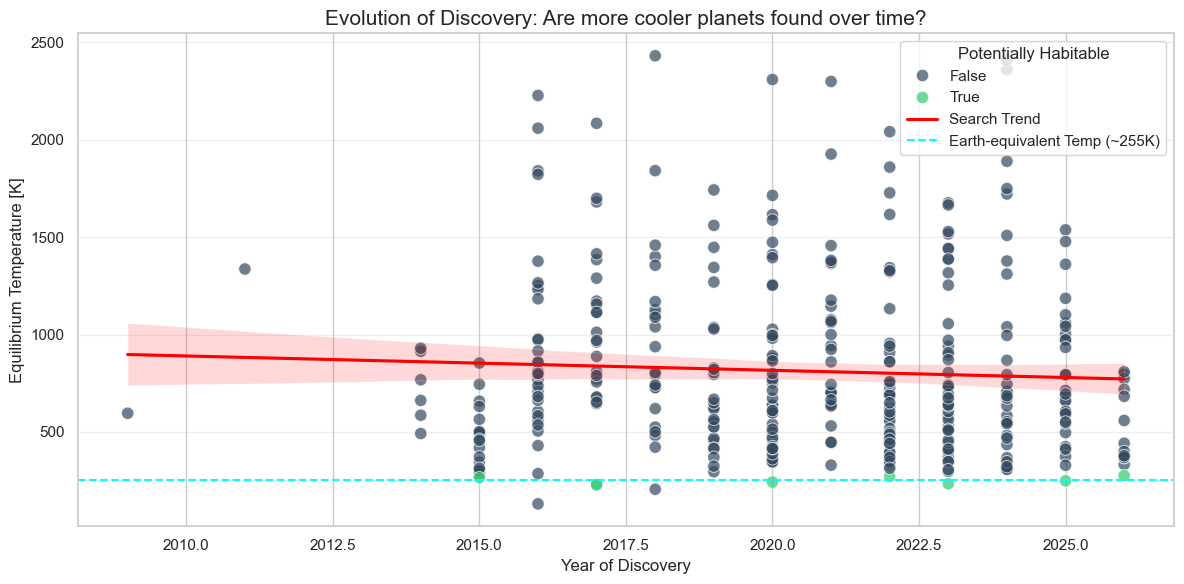

In [216]:
# Sets up the plot.
plt.figure(figsize = (12, 6))

sns.scatterplot(
    data = planet_df,
    x = 'disc_year',
    y = 'pl_eqt',
    hue = 'habitable',
    palette = {True: '#2ecc71', False: '#34495e'},
    alpha = 0.7,
    s = 80
)

# Adds a regression trend line to see the change in average temp. over time.
sns.regplot(
    data = planet_df,
    x = 'disc_year',
    y = 'pl_eqt',
    scatter = False,
    color = 'red',
    label = 'Search Trend'
)

# Adds a reference line for Earth's equilibrium Temperature (~255K).
plt.axhline(255, color = 'cyan', linestyle = '--', label = 'Earth-equivalent Temp (~255K)')

plt.title('Evolution of Discovery: Are more cooler planets found over time?', fontsize = 15)
plt.xlabel('Year of Discovery', fontsize = 12)
plt.ylabel('Equilibrium Temperature [K]', fontsize = 12)
plt.legend(title = 'Potentially Habitable', loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

**Interpretation:** This plot shows the trend of average exoplanet equilibrium temperatures discovered over time.

The trend line is very slightly negative, which does suggest that the progress of discovering more cooler planets (rather than hotter planets) is slightly improving over time. This idea is also visible in how the potentially habitable exoplanets (green sample points in the plot) are being discovered in the later years of the dataset.

However, it is not significant enough to indicate that more recent observations are changing the current understanding of habitable exoplanets.

A possible theory could be that the technology needed to detect more exoplanets (that are potentially habitable) orbiting the known stars in the dataset does not yet exist, or does not yet exist in a usable state.

### Visualization 6: Discovery Method Bar Chart

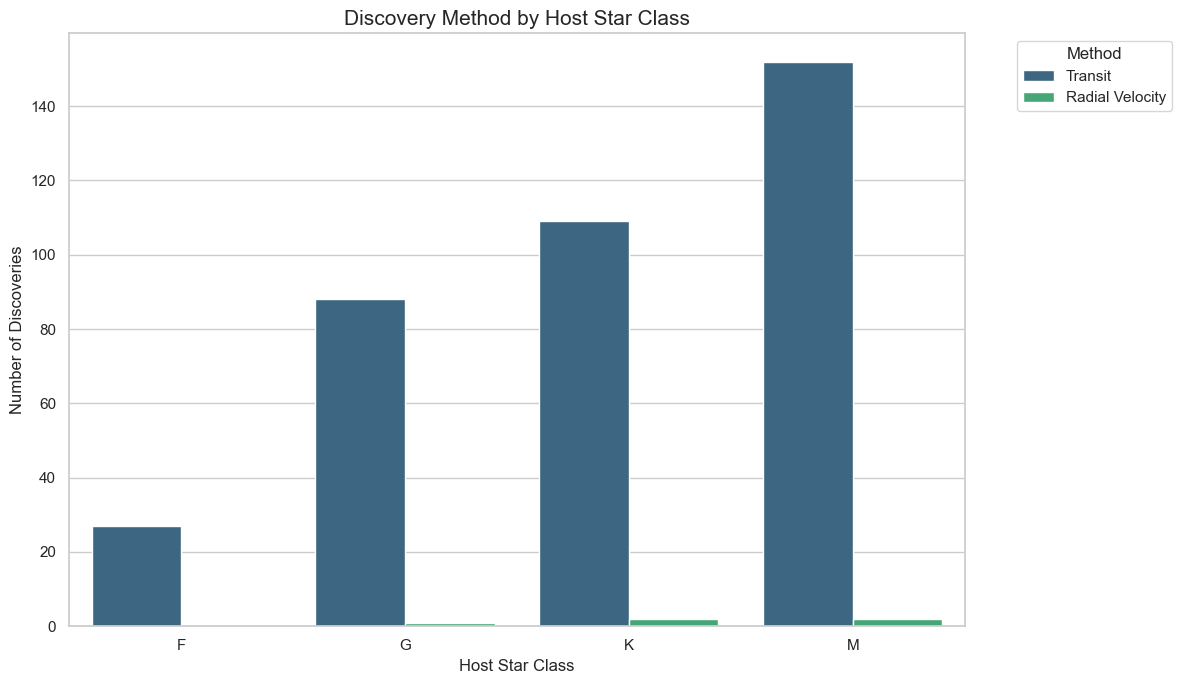

In [217]:
# Sets up the plot.
plt.figure(figsize = (12, 7 ))

# Creates a bar chart to see the count of which discovery methods find which planets.
star_order = ['F', 'G', 'K', 'M']

sns.countplot(
    data = planet_df,
    x = 'host_star_class',
    hue = 'discoverymethod',
    order = star_order,
    palette = 'viridis'
)

plt.title('Discovery Method by Host Star Class', fontsize = 15)
plt.xlabel('Host Star Class', fontsize = 12)
plt.ylabel('Number of Discoveries', fontsize = 12)
plt.legend(title = 'Method', bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

**Interpretation:** This plot shows the discovery methods used for each exoplanet in the sample (categorized by host star class).

Most of the exoplanets in the sample were discovered by observing the exoplanet when it is "in transit" and positions itself between Earth and its host star (allowing observations of the host star dimming when this happens).

This visualization indicates that the observations are biased because the Transit method is really only good at detecting planets that orbit their host stars very closely. So, the data points in the current dataset are weighted toward high-temperature environments.

This helps expound on the idea that the scarcity of habitable planets in the dataset is possibly a result of discovery technology or methods used rather than a true, conclusive lack of habitable planets.

## Summary of Initial Findings

The work done in this notebook so far has looked at the relations that exist between various stellar and planetary parameters from the dataset. By starting with a bar chart that visualized the relation between the number of exoplanets and the host star class, it was observed that a large majority of the exoplanets orbit the star-types with cooler temperatures (either K-type or M-type).

The second visualization shows the correlation strength between multiple planetary and secondary parameters. From this heatmap, it was observed that a strong positive correlation exists between a planet's equilibrium temperature and the insolation flux. This is significant because it expresses that the energy that a star outputs has an effect on the equilibrium temperature of the planet orbiting it.



## Hypothesis for Further Exploration

TODO